In [3]:
import matplotlib.pyplot as plt
import numpy as np
import tqdm

In [4]:
train_1 = np.load("data_1.npz")["arr_0"]
train_2 = np.load("data_2.npz")["arr_0"]

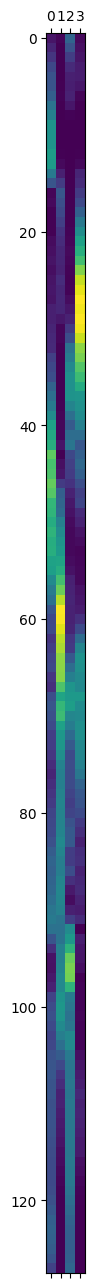

In [53]:
plt.matshow(train_1[0])

In [ ]:
# 128, 4 --> 128, 1, 3
# 4, 128 --> 3, 1, 128

# 128, 128, 3 --> RGB

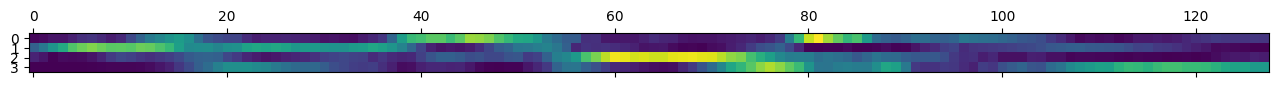

In [54]:
plt.matshow(train_2[0])

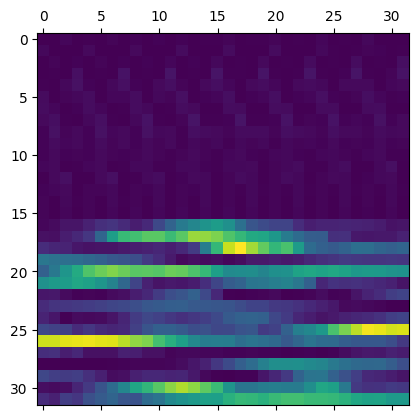

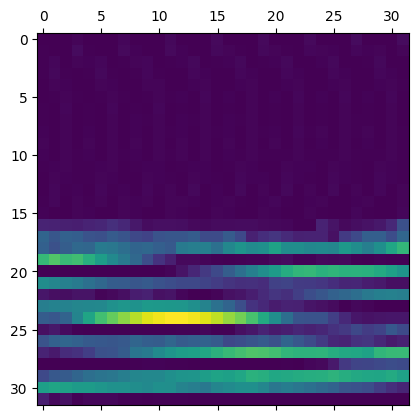

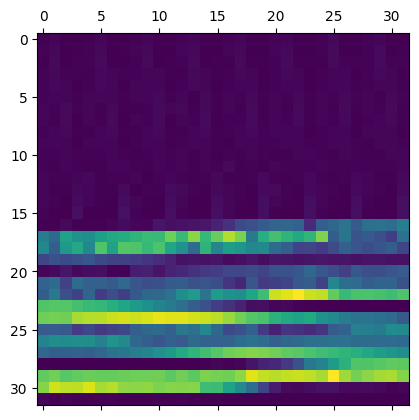

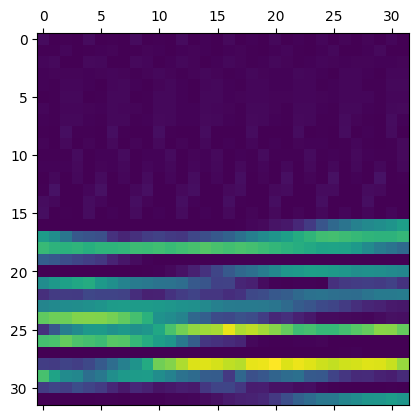

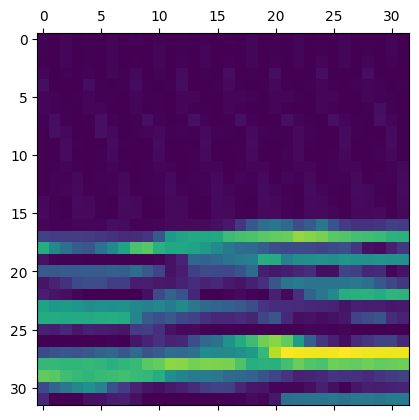

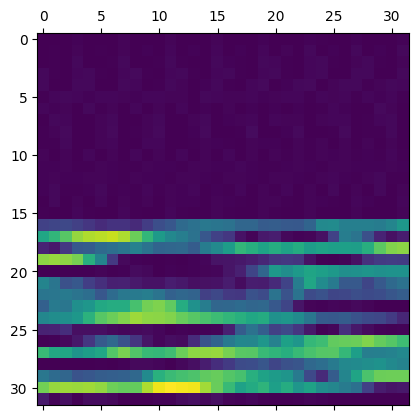

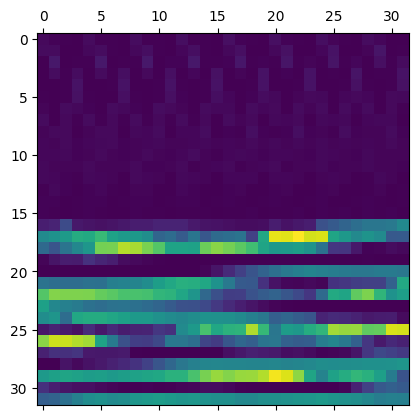

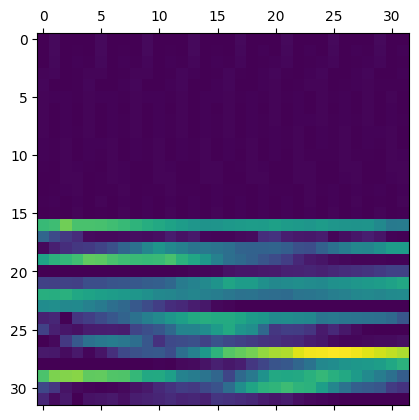

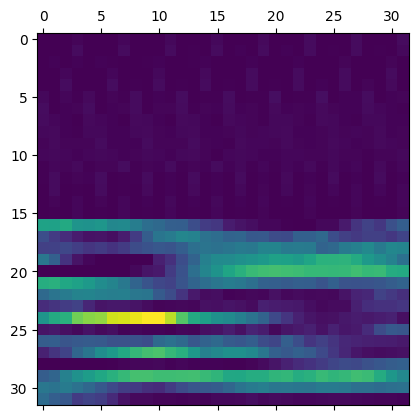

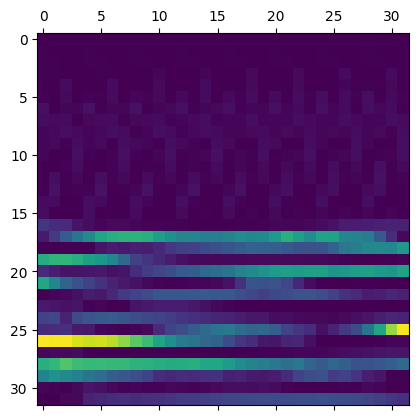

In [57]:

for i in range(10):
    img_1 = np.append(train_1[i].reshape(-1), train_2[i].reshape(-1)).reshape((32, 32))
    plt.matshow(img_1)
    plt.show()

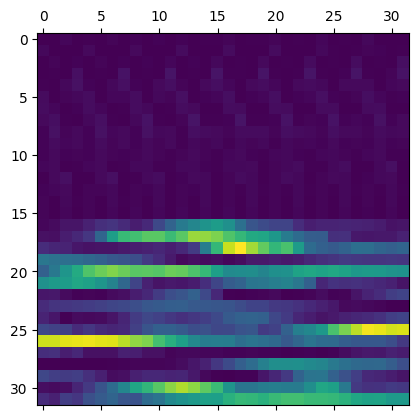

In [56]:
plt.matshow(img_1)

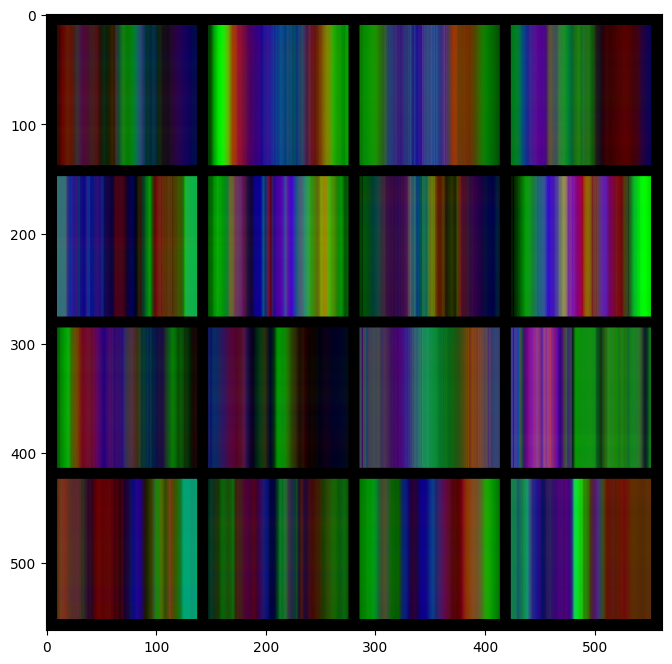

In [5]:
import torch    
from torchvision.utils import make_grid

def create_images_dataset(x1, x2, show_images=16):
    images = []
    
    for i in range(int(x1.shape[0])):
        x1_expanded = np.expand_dims(x1[i][0:, 1:4], axis=2)
        x2_expanded = np.expand_dims(x2[i][1:4], axis=0) 
        # print(x1_expanded.shape, x2_expanded.shape)
        result = x1_expanded + x2_expanded
        # print(result.shape)
        
        result_tensor = torch.tensor(result / 129.63779, dtype=torch.float32).permute((0, 2, 1))
        
        images.append(result_tensor)
        if len(images) == show_images:
            images_tensor = torch.stack(images).permute(0, 3, 1, 2)
            
            grid = make_grid(images_tensor, nrow=int(np.sqrt(show_images)), padding = 10)

            plt.figure(figsize = (8, 8))
            plt.imshow(grid.permute(1, 2, 0))
            plt.show()

    return torch.stack(images).numpy()
ds = create_images_dataset(train_1, train_2)

In [31]:
feat = ds

In [33]:
feat.shape

(3840, 128, 128, 3)

In [40]:
new_feat = []

for i in tqdm.tqdm(range(len(feat))):
    new_feat.append(feat[i][0])

new_feat = np.array(new_feat)

100%|██████████| 3840/3840 [00:00<00:00, 751358.81it/s]


In [71]:
new_feat.shape

(3840, 128, 3)

In [88]:
new_new_feat = []

for i in range(len(new_feat)):
    new_list = []
    med = 0;

    for j in range(len(new_feat[i])):
        if((j + 1) % 8 == 0):
            med /= 8;
            new_list.append(med)
            med = 0;            
        
        med += new_feat[i][j].sum() / 3;
    new_new_feat.append(new_list)
        

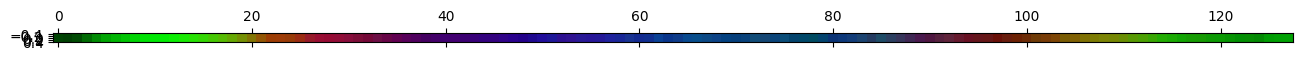

In [89]:
plt.matshow([new_feat[1]])

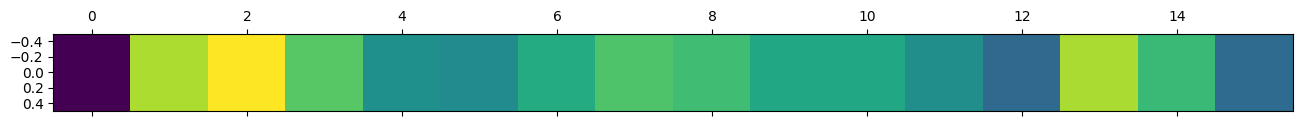

In [90]:
plt.matshow([new_new_feat[1]])

In [91]:
from sklearn.decomposition import *
from sklearn.cluster import KMeans

In [92]:
feat = np.array(new_new_feat).reshape(feat.shape[0], -1)

In [93]:
points_ = PCA(2).fit_transform(feat)

In [94]:
md = KMeans(32)

pred = md.fit_predict(feat)

In [95]:
md.cluster_centers_

array([[0.19365444, 0.27985985, 0.31445314, 0.32303672, 0.28581216,
        0.25033964, 0.2301576 , 0.23694438, 0.23039704, 0.22077762,
        0.20408874, 0.19415891, 0.19739843, 0.24273375, 0.22277514,
        0.17336925],
       [0.08768253, 0.1359871 , 0.16117799, 0.16965015, 0.1601103 ,
        0.15719811, 0.17451331, 0.19309503, 0.19828168, 0.21744379,
        0.22412024, 0.2215456 , 0.19130193, 0.18138947, 0.15554473,
        0.11847682],
       [0.08778267, 0.13841409, 0.1616489 , 0.1870992 , 0.19718612,
        0.2257107 , 0.26474662, 0.2966843 , 0.30210984, 0.30375076,
        0.29172693, 0.26783204, 0.23811899, 0.24209745, 0.22166705,
        0.1667634 ],
       [0.19220822, 0.2396515 , 0.2266528 , 0.21273766, 0.19247475,
        0.18714167, 0.20116655, 0.22798671, 0.23058663, 0.22504638,
        0.21389406, 0.20772395, 0.19541681, 0.19875189, 0.18924044,
        0.16953692],
       [0.17103313, 0.21234499, 0.21889512, 0.23686824, 0.26488925,
        0.3018396 , 0.34722175, 

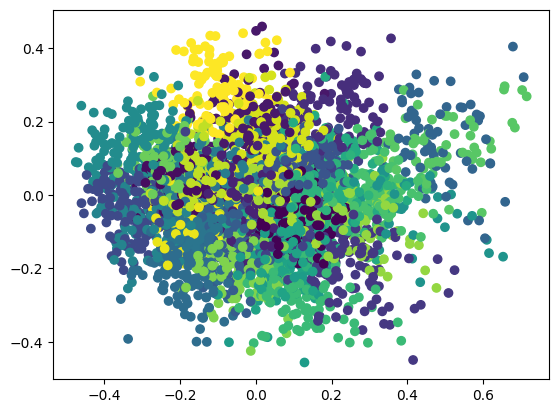

In [96]:
plt.scatter(points_[:, 0], points_[:, 1], c=pred)

In [97]:
f = open("ans.csv", 'w')

f.write("id,target\n");

for i in range(feat.shape[0]):
    f.write("{i},{p}\n".format(i=i, p=pred[i]))

f.close()